<a href="https://colab.research.google.com/github/sadhika-tech/deep-learning-lab/blob/main/Lab%201/or_and_not_perceptron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Step Activation function
def step (z):
  if z>=0:
    return 1

  else:
    return 0

In [ ]:
#Decision boundary for OR and AND
def decision_boundary(x,y,w,b,title):

    label0=True
    label1=True
    plt.figure(figsize=(5,5))
    for i in range(len(x)):
        if y[i]==0:
          if label0:
            plt.scatter(x[i][0],x[i][1],color='red',label="Output=0")
            label0=False
          else:
            plt.scatter(x[i][0],x[i][1],color='red')
        else:
          if label1:
            plt.scatter(x[i][0],x[i][1],color='blue',label="Output=1")
            label1=False
          else:
            plt.scatter(x[i][0],x[i][1],color='blue')
    x_cord=np.linspace(-0.5,1.5,5)

    if w[1]!=0:
        boundary=-(w[0]*x_cord+b)/w[1]
        plt.plot(x_cord,boundary,color='black',label="Decision Boundary")
    else:
        plt.axvline(-b/w[0])
    plt.title(title)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.savefig(f"{title}.eps",dpi=600)
    plt.legend()
    plt.show()

In [ ]:
#Perceptron for AND and OR
def perceptron(x,y,gate):
    w=np.zeros(2)
    b=0
    lr=1
    update=1

    for epoch in range(10):
        error=False
        for i in range(len(x)):
            z=np.dot(w,x[i])+b
            pred=step(z)
            err=y[i]-pred
            if err!=0:
                w=w+(lr*err*x[i])
                b=b+(lr*err)

                print("\n\nUpdate",update)
                print("Weights =",w)
                print("Bias =",b)

                update+=1
                error=True

        if error==False:
            break

    print("\nFinal Weights:",w)
    print("Final Bias:",b)

    decision_boundary(x,y,w,b,gate+f"(Update= {update-1})")

    print("\nPredictions")
    for i in x:
        print(i," | ",step(np.dot(w,i)+b))


AND Gate


Update 1
Weights = [0. 0.]
Bias = -1


Update 2
Weights = [1. 1.]
Bias = 0


Update 3
Weights = [1. 1.]
Bias = -1


Update 4
Weights = [1. 0.]
Bias = -2


Update 5
Weights = [2. 1.]
Bias = -1


Update 6
Weights = [2. 0.]
Bias = -2


Update 7
Weights = [1. 0.]
Bias = -3


Update 8
Weights = [2. 1.]
Bias = -2


Update 9
Weights = [1. 1.]
Bias = -3


Update 10
Weights = [2. 2.]
Bias = -2


Update 11
Weights = [2. 1.]
Bias = -3

Final Weights: [2. 1.]
Final Bias: -3


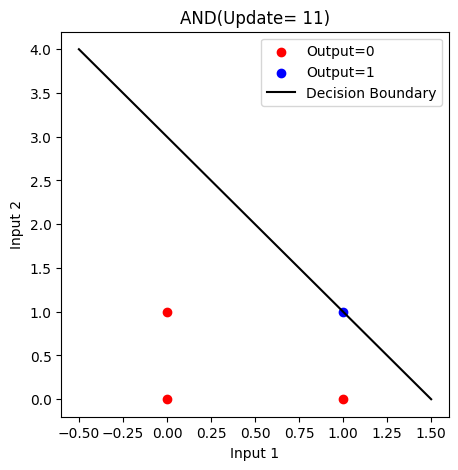


Predictions
[0 0]  |  0
[0 1]  |  0
[1 0]  |  0
[1 1]  |  1


In [ ]:
#AND Gate
x=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,0,0,1])

print("AND Gate")
perceptron(x,y,"AND")

OR Gate


Update 1
Weights = [0. 0.]
Bias = -1


Update 2
Weights = [0. 1.]
Bias = 0


Update 3
Weights = [0. 1.]
Bias = -1


Update 4
Weights = [1. 1.]
Bias = 0


Update 5
Weights = [1. 1.]
Bias = -1

Final Weights: [1. 1.]
Final Bias: -1


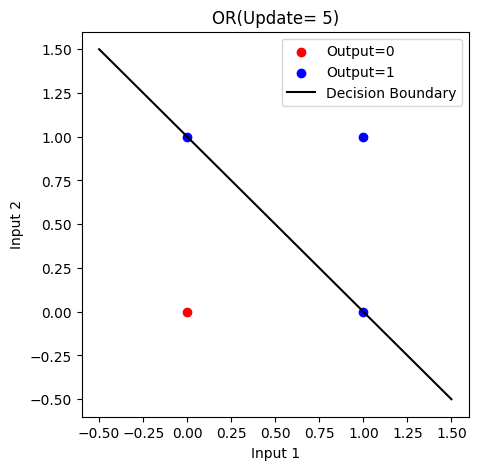


Predictions
[0 0]  |  0
[0 1]  |  1
[1 0]  |  1
[1 1]  |  1


In [ ]:
#OR Gate
x=np.array([[0,0],[0,1],[1,0],[1,1]])
y=np.array([0,1,1,1])

print("OR Gate")
perceptron(x,y,"OR")

In [ ]:
def db_not(x,y,w,b,title):
    plt.figure(figsize=(5,5))
    for i in range(len(x)):
        if y[i]==0:
          plt.scatter(x[i][0],0,color='red',label="Output=0")
        else:
            plt.scatter(x[i][0],0,color='blue',label="Output=1")
    x=np.linspace(-0.5,1.5,5)

    if w[0]!=0:
        plt.axvline(-b/w[0],color='black',label='Decision Boundary')
    plt.title(title)
    plt.xlabel("Input 1")
    plt.savefig(f"{title}.eps",dpi=600)
    plt.legend()
    plt.show()

In [ ]:
#Perceptron for NOT Gate
def perceptron_not(x,y):
    w=np.zeros(1)
    b=0
    lr=1
    update=1

    for epoch in range(10):
        error=False

        for i in range(len(x)):
            pred=step(np.dot(w, x[i])+b)
            err=y[i]-pred

            if err!=0:
                w=w+(lr*err*x[i])
                b=b+(lr*err)
                print("\nUpdate= ",update)
                print("Weights= ",w)
                print("Bias= ",b)

                update+=1
                error=True

        if not error:
            break

    print("\nFinal Weights:",w)
    print("Final Bias:",b)
    db_not(x,y,w,b,f"NOT Update= {update-1}")

    print("\nPredictions")
    for i in x:
        print(i," | ",step(np.dot(w,i)+b))




NOT Gate

Update=  1
Weights=  [-1.]
Bias=  -1

Update=  2
Weights=  [-1.]
Bias=  0

Final Weights: [-1.]
Final Bias: 0


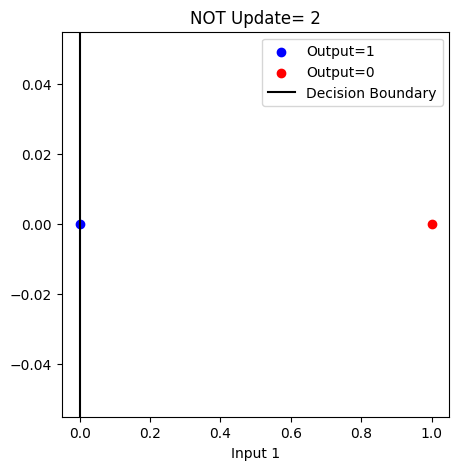


Predictions
[0]  |  1
[1]  |  0


In [ ]:
x=np.array([[0],[1]])
y= np.array([1,0])

print("\nNOT Gate")
perceptron_not(x,y)